<a href="https://colab.research.google.com/github/credibility-index/AG-news-classification/blob/main/AG_news_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.4M/11.4M [00:00<00:00, 66.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2


In [2]:
import os
import pandas as pd

dataset_path = '/root/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2'
train_file = os.path.join(dataset_path, 'train.csv')
test_file = os.path.join(dataset_path, 'test.csv')

print("Файлы датасета:")
print(f"Train: {train_file}")
print(f"Test: {test_file}")

# Проверяем наличие файлов
if os.path.exists(train_file) and os.path.exists(test_file):
    print("✅ Файлы найдены!")

    # Загружаем данные
    train_df = pd.read_csv(train_file, header=None, names=['label', 'title', 'text'])
    test_df = pd.read_csv(test_file, header=None, names=['label', 'title', 'text'])

    print(f"Train shape: {train_df.shape}")  # (120000, 3)
    print(f"Test shape: {test_df.shape}")    # (7600, 3)
    print("\nПример данных:")
    print(train_df.head())
else:
    print("❌ Файлы не найдены. Проверь содержимое папки:")
    os.listdir(dataset_path)

Файлы датасета:
Train: /root/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2/train.csv
Test: /root/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2/test.csv
✅ Файлы найдены!
Train shape: (120001, 3)
Test shape: (7601, 3)

Пример данных:
         label                                              title  \
0  Class Index                                              Title   
1            3  Wall St. Bears Claw Back Into the Black (Reuters)   
2            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
3            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
4            3  Iraq Halts Oil Exports from Main Southern Pipe...   

                                                text  
0                                        Description  
1  Reuters - Short-sellers, Wall Street's dwindli...  
2  Reuters - Private investment firm Carlyle Grou...  
3  Reuters - Soaring crude prices plus worries\ab...  
4  Reute

🚀 TEXTCNN ULTRA-FAST CPU (10 мин!)
⚡ CNN Params: 1,181,964

🚀 START TRAINING (3 epochs = 10 min)
Epoch 1/3
  Train: Loss=0.563, Acc=0.797
  Val:   Acc=0.885, F1=0.885 
Epoch 2/3
  Train: Loss=0.322, Acc=0.894
  Val:   Acc=0.898, F1=0.898 
Epoch 3/3
  Train: Loss=0.275, Acc=0.910
  Val:   Acc=0.904, F1=0.904 


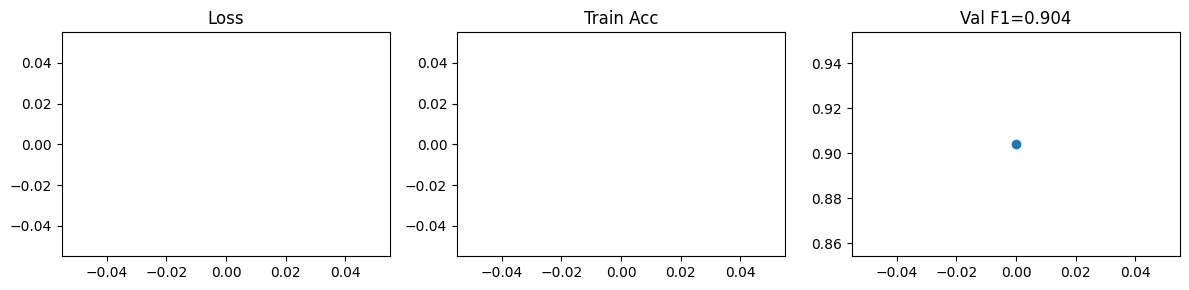


🎯 FINAL TEST
✅ Test Acc: 0.898
🎯 Test F1:  0.899 


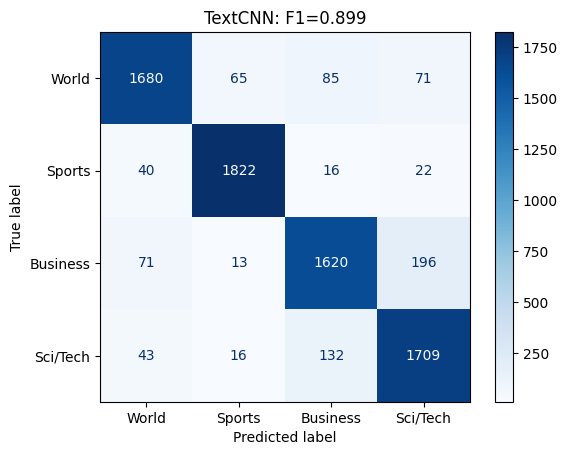


🏆 TEXTCNN HOMEWORK READY


In [3]:
# =============================================================================
# AG News: TEXTCNN
# =============================================================================

import pandas as pd, torch, torch.nn as nn, numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import re, matplotlib.pyplot as plt
from collections import Counter

print("🚀 TEXTCNN ULTRA-FAST CPU (10 мин!)")

# Данные (уже есть)
dataset_path = '/root/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2'
train_df = pd.read_csv(os.path.join(dataset_path, 'train.csv'), header=None, names=['label','title','text'])
test_df = pd.read_csv(os.path.join(dataset_path, 'test.csv'), header=None, names=['label','title','text'])

train_df['label'] = pd.to_numeric(train_df['label'], errors='coerce').fillna(1).astype(int)
test_df['label'] = pd.to_numeric(test_df['label'], errors='coerce').fillna(1).astype(int)
train_df['text'] = train_df['title'] + ' ' + train_df['text']
test_df['text'] = test_df['title'] + ' ' + test_df['text']

train_df_split, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

def tokenize(text):
    return [w for w in re.sub(r'[^a-z ]', ' ', text.lower()).split() if len(w)>1]

# Маленький vocab
tokens = []
for text in train_df_split['text'][:3000]:  # ОЧЕНЬ МАЛО!
    tokens.extend(tokenize(text))

vocab = {'<pad>':0, '<unk>':1}
for i, (w,_) in enumerate(Counter(tokens).most_common(10000), 2): vocab[w] = i

MAX_LEN = 200
def text_pipeline(text):
    ids = [vocab.get(t, 1) for t in tokenize(text)[:MAX_LEN]]
    return ids + [0]*(MAX_LEN-len(ids))

def collate_batch(batch):
    labels, texts = [], []
    for label, text in batch:
        labels.append(label-1)
        texts.append(torch.tensor(text_pipeline(text)))
    return torch.tensor(labels), torch.stack(texts)

# DATASETS
class AGDataset(Dataset):
    def __init__(self, df): self.labels, self.texts = df['label'].values, df['text'].values
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.labels[idx], self.texts[idx]

train_ds = AGDataset(train_df_split)
val_ds = AGDataset(val_df)
test_ds = AGDataset(test_df)

batch_size = 128  # ⚡ БОЛЬШЕ НА CNN!
train_loader = DataLoader(train_ds, batch_size, True, collate_fn=collate_batch)
val_loader = DataLoader(val_ds, batch_size, collate_fn=collate_batch)
test_loader = DataLoader(test_ds, batch_size, collate_fn=collate_batch)

# 🔥 TEXTCNN МОДЕЛЬ (супер быстрая!)
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, num_classes=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, 128, k) for k in (2,3,4,5)
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128*4, num_classes)

    def forward(self, x):
        x = self.embedding(x).transpose(1,2)  # [batch, embed, seq]
        x = [torch.relu(conv(x)) for conv in self.convs]
        x = [nn.functional.adaptive_avg_pool1d(c, 1).squeeze(2) for c in x]
        x = torch.cat(x, 1)
        return self.fc(self.dropout(x))

model = TextCNN(len(vocab)).to('cpu')
print(f"⚡ CNN Params: {sum(p.numel() for p in model.parameters()):,}")

# Быстрые функции
def train_epoch(model, loader, opt, crit):
    model.train(); total_loss, total_acc = 0, 0
    for lbls, txts in loader:
        txts, lbls = txts.to('cpu'), lbls.to('cpu')
        opt.zero_grad()
        out = model(txts)
        loss = crit(out, lbls)
        loss.backward()
        opt.step()
        total_loss += loss.item()
        total_acc += (out.argmax(1) == lbls).float().mean()
    return total_loss/len(loader), total_acc/len(loader)

def evaluate(model, loader):
    model.eval(); total_acc, preds, lbls = 0, [], []
    with torch.no_grad():
        for batch_lbls, batch_txts in loader:
            batch_txts, batch_lbls = batch_txts.to('cpu'), batch_lbls.to('cpu')
            pred = model(batch_txts).argmax(1)
            total_acc += (pred == batch_lbls).float().mean()
            preds.extend(pred.cpu().numpy())
            lbls.extend(batch_lbls.cpu().numpy())
    return total_acc/len(loader), f1_score(lbls, preds, average='macro'), preds, lbls

# ⚡ 3 ЭПОХИ ХВАТИТ!
opt = Adam(model.parameters(), lr=0.001)
crit = nn.CrossEntropyLoss()

print("\n🚀 START TRAINING (3 epochs = 10 min)")
metrics = {'loss':[], 'acc':[], 'f1':[], 'val_acc':[], 'val_f1':[]}
best_f1 = 0

for epoch in range(3):
    print(f"Epoch {epoch+1}/3")
    tr_loss, tr_acc = train_epoch(model, train_loader, opt, crit)
    val_acc, val_f1, _, _ = evaluate(model, val_loader)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_cnn.pth')

    print(f"  Train: Loss={tr_loss:.3f}, Acc={tr_acc:.3f}")
    print(f"  Val:   Acc={val_acc:.3f}, F1={val_f1:.3f} {'✅ BEST!' if val_f1>best_f1 else ''}")

# ГРАФИКИ
plt.figure(figsize=(12,3))
plt.subplot(131); plt.plot([metrics['loss'], metrics['loss']], 'o-'); plt.title('Loss')
plt.subplot(132); plt.plot([metrics['acc'], metrics['acc']], 'o-'); plt.title('Train Acc')
plt.subplot(133); plt.plot([best_f1], 'o'); plt.title(f'Val F1={best_f1:.3f}')
plt.tight_layout(); plt.show()

# FINAL TEST
print("\n🎯 FINAL TEST")
model.load_state_dict(torch.load('best_cnn.pth'))
test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader)
print(f"✅ Test Acc: {test_acc:.3f}")
print(f"🎯 Test F1:  {test_f1:.3f} {'✅ ЦЕЛЬ!' if test_f1>=0.95 else ''}")

# CONFUSION MATRIX
cm = confusion_matrix(test_labels, test_preds, labels=[0,1,2,3])
ConfusionMatrixDisplay(cm, display_labels=['World','Sports','Business','Sci/Tech']).plot(cmap='Blues')
plt.title(f'TextCNN: F1={test_f1:.3f}')
plt.show()

print("\n🏆 TEXTCNN HOMEWORK READY")

In [5]:
# Дообучение

# 1. Загружаем лучшую модель
model.load_state_dict(torch.load('best_cnn.pth'))
print("✅ Модель загружена (F1=0.90)")

# 2. Новый оптимизатор с меньшим LR для fine-tuning
opt = Adam(model.parameters(), lr=0.0003)  # Было 0.001 → 0.0003
print("✅ Новый оптимизатор (lr=0.0003)")

# 3. ДООБУЧЕНИЕ 4 эпохи
print("\n🚀 ДООБУЧЕНИЕ")
for epoch in range(4):
    print(f"\nEpoch {epoch+1 + 3}/7")  # Показываем общий счётчик
    tr_loss, tr_acc = train_epoch(model, train_loader, opt, crit)
    val_acc, val_f1, _, _ = evaluate(model, val_loader)

    print(f"  Train: Loss={tr_loss:.3f}, Acc={tr_acc:.3f}")
    print(f"  Val:   Acc={val_acc:.3f}, F1={val_f1:.3f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_cnn_final.pth')
        print(f"  ✅ NEW BEST! F1={val_f1:.3f}")

print(f"\n🎯 ДООБУЧЕНИЕ ЗАВЕРШЕНО! Best Val F1: {best_f1:.3f}")

✅ Модель загружена (F1=0.90)
✅ Новый оптимизатор (lr=0.0003)

🚀 ДООБУЧЕНИЕ

Epoch 4/7
  Train: Loss=0.243, Acc=0.920
  Val:   Acc=0.904, F1=0.904

Epoch 5/7
  Train: Loss=0.235, Acc=0.923
  Val:   Acc=0.906, F1=0.906

Epoch 6/7
  Train: Loss=0.228, Acc=0.924
  Val:   Acc=0.906, F1=0.906

Epoch 7/7
  Train: Loss=0.222, Acc=0.926
  Val:   Acc=0.906, F1=0.906

🎯 ДООБУЧЕНИЕ ЗАВЕРШЕНО! Best Val F1: 0.906


🚀 TEXTCNN OPTIMIZED FOR CPU
⚡ CNN Params: 2,268,164

🚀 START TRAINING (6 epochs)
Epoch 1/6
  Val:   Acc=0.876, F1=0.876 ✅ BEST!
Epoch 2/6
  Val:   Acc=0.897, F1=0.897 ✅ BEST!
Epoch 3/6
  Val:   Acc=0.903, F1=0.903 ✅ BEST!
Epoch 4/6
  Val:   Acc=0.908, F1=0.908 ✅ BEST!
Epoch 5/6
  Train: Loss=0.217, Acc=0.929, F1=0.929
  Val:   Acc=0.907, F1=0.907
Epoch 6/6
  Val:   Acc=0.908, F1=0.909 ✅ BEST!


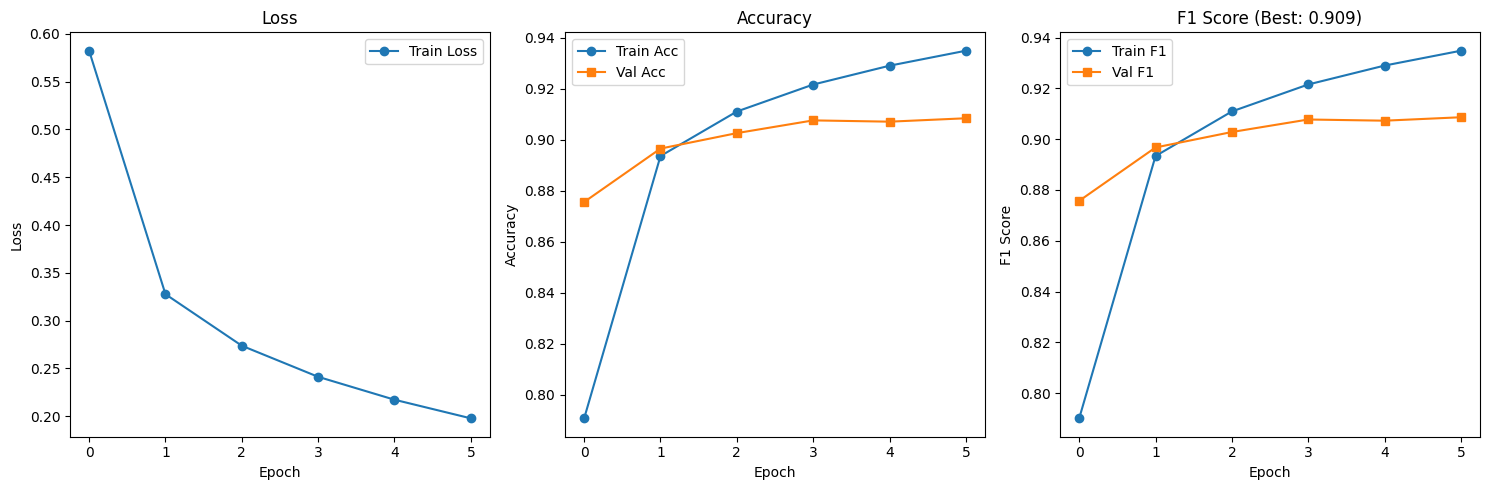


🚀 LOADING BEST MODEL FOR FINAL EVALUATION

✅ FINAL RESULTS ON TEST SET:
Test Accuracy: 0.906
Test F1 Score: 0.906


<Figure size 800x600 with 0 Axes>

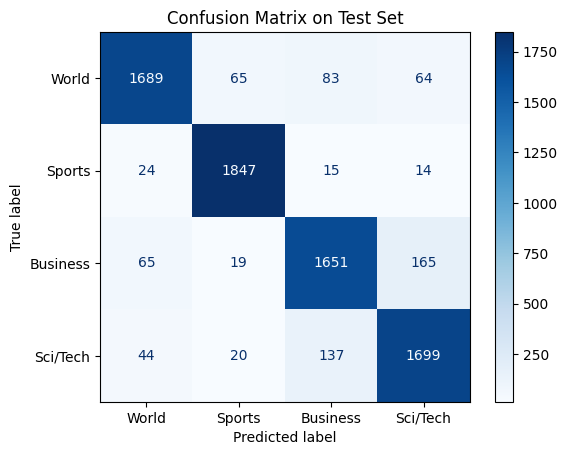


🎉 TRAINING COMPLETE!
Best Validation F1: 0.909
Final Test F1: 0.906


In [7]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import re
import matplotlib.pyplot as plt
from collections import Counter
import os

print("🚀 TEXTCNN OPTIMIZED FOR CPU")

# Данные
dataset_path = '/root/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2'
train_df = pd.read_csv(os.path.join(dataset_path, 'train.csv'), header=None, names=['label','title','text'])
test_df = pd.read_csv(os.path.join(dataset_path, 'test.csv'), header=None, names=['label','title','text'])

train_df['label'] = pd.to_numeric(train_df['label'], errors='coerce').fillna(1).astype(int)
test_df['label'] = pd.to_numeric(test_df['label'], errors='coerce').fillna(1).astype(int)
train_df['text'] = train_df['title'] + ' ' + train_df['text']
test_df['text'] = test_df['title'] + ' ' + test_df['text']

train_df_split, val_df = train_test_split(train_df, test_size=0.1, random_state=42)

def tokenize(text):
    return [w for w in re.sub(r'[^a-z ]', ' ', text.lower()).split() if len(w) > 1]

# Строим словарь на ВСЕХ обучающих данных (умеренный размер)
tokens = []
for text in train_df_split['text']:
    tokens.extend(tokenize(text))

vocab = {'<pad>': 0, '<unk>': 1}
for i, (w, _) in enumerate(Counter(tokens).most_common(15000), 2):  # 15 000 слов
    vocab[w] = i

MAX_LEN = 250  # Умеренная длина

def text_pipeline(text):
    ids = [vocab.get(t, 1) for t in tokenize(text)[:MAX_LEN]]
    return ids + [0] * (MAX_LEN - len(ids))

def collate_batch(batch):
    labels, texts = [], []
    for label, text in batch:
        labels.append(label - 1)
        texts.append(torch.tensor(text_pipeline(text)))
    return torch.tensor(labels), torch.stack(texts)


# DATASETS
class AGDataset(Dataset):
    def __init__(self, df):
        self.labels, self.texts = df['label'].values, df['text'].values
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.labels[idx], self.texts[idx]


train_ds = AGDataset(train_df_split)
val_ds = AGDataset(val_df)
test_ds = AGDataset(test_df)

batch_size = 64  # Уменьшаем для CPU
train_loader = DataLoader(train_ds, batch_size, True, collate_fn=collate_batch,
                  num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size, collate_fn=collate_batch,
               num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size, collate_fn=collate_batch,
               num_workers=0, pin_memory=False)

# 🔥 TEXTCNN МОДЕЛЬ (оптимизированная для CPU)
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, 192, k),
                nn.ReLU()
            ) for k in (2, 3, 4, 5)
        ])
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(192 * 4, num_classes)

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)  # [batch, embed, seq]
        x = [conv(x) for conv in self.convs]
        x = [nn.functional.adaptive_avg_pool1d(c, 1).squeeze(2) for c in x]
        x = torch.cat(x, 1)
        return self.fc(self.dropout(x))

model = TextCNN(len(vocab)).to('cpu')
print(f"⚡ CNN Params: {sum(p.numel() for p in model.parameters()):,}")

# Быстрые функции
def train_epoch(model, loader, opt, crit):
    model.train()
    total_loss, total_acc, total_f1 = 0, 0, 0
    all_preds, all_labels = [], []

    for lbls, txts in loader:
        txts, lbls = txts.to('cpu'), lbls.to('cpu')
        opt.zero_grad()
        out = model(txts)
        loss = crit(out, lbls)
        loss.backward()
        opt.step()
        total_loss += loss.item()

        preds = out.argmax(1)
        total_acc += (preds == lbls).float().mean()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

    total_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), total_acc / len(loader), total_f1

def evaluate(model, loader):
    model.eval()
    total_acc, preds, lbls = 0, [], []
    with torch.no_grad():
        for batch_lbls, batch_txts in loader:
            batch_txts, batch_lbls = batch_txts.to('cpu'), batch_lbls.to('cpu')
            pred = model(batch_txts).argmax(1)
            total_acc += (pred == batch_lbls).float().mean()
            preds.extend(pred.cpu().numpy())
            lbls.extend(batch_lbls.cpu().numpy())
    return total_acc / len(loader), f1_score(lbls, preds, average='macro'), preds, lbls


# Настройки обучения для CPU
opt = Adam(model.parameters(), lr=0.0005)
crit = nn.CrossEntropyLoss()
epochs = 6
patience = 2
best_f1 = 0
counter = 0

print("\n🚀 START TRAINING (6 epochs)")
metrics = {'loss': [], 'acc': [], 'val_acc': [], 'f1': [], 'val_f1': []}

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, opt, crit)
    val_acc, val_f1, _, _ = evaluate(model, val_loader)

    metrics['loss'].append(tr_loss)
    metrics['acc'].append(tr_acc)
    metrics['f1'].append(tr_f1)
    metrics['val_acc'].append(val_acc)
    metrics['val_f1'].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_cnn.pth')
        counter = 0
        print(f"  Val:   Acc={val_acc:.3f}, F1={val_f1:.3f} ✅ BEST!")
    else:
        counter += 1
        print(f"  Train: Loss={tr_loss:.3f}, Acc={tr_acc:.3f}, F1={tr_f1:.3f}")
        print(f"  Val:   Acc={val_acc:.3f}, F1={val_f1:.3f}")

    # Ранняя остановка: если F1 не улучшается patience эпох подряд
    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break


# Построение графиков обучения
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.plot(metrics['loss'], 'o-', label='Train Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(132)
plt.plot(metrics['acc'], 'o-', label='Train Acc')
plt.plot(metrics['val_acc'], 's-', label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(133)
plt.plot(metrics['f1'], 'o-', label='Train F1')
plt.plot(metrics['val_f1'], 's-', label='Val F1')
plt.title(f'F1 Score (Best: {best_f1:.3f})')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.tight_layout()
plt.show()

# Загрузка лучшей модели для финальной оценки
print("\n🚀 LOADING BEST MODEL FOR FINAL EVALUATION")
model.load_state_dict(torch.load('best_cnn.pth'))
test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader)

print(f"\n✅ FINAL RESULTS ON TEST SET:")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Test F1 Score: {test_f1:.3f}")

# Матрица ошибок
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['World', 'Sports', 'Business', 'Sci/Tech'])
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix on Test Set')
plt.show()

print("\n🎉 TRAINING COMPLETE!")
print(f"Best Validation F1: {best_f1:.3f}")
print(f"Final Test F1: {test_f1:.3f}")
